# **Project Title : Traffic Sign Recognition System**

#### Install Libraries and APIs that are not available but required

In [27]:
# !python -m pip install --upgrade pip

In [28]:
# Installed this library for this needed later to show model summary 
# !python -m pip install opencv-contrib-python

#### Import Libraries and APIs

In [29]:
# !python --version

In [30]:
#!python -m pip uninstall torch torchvision torchaudio -y

In [31]:
#!python -m pip uninstall numpy -y

In [32]:
# !python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --proxy=""

In [33]:
import gc, os, cv2, PIL, torch
import torchvision as tv
import torch.nn as nn
import torchsummary as ts
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#### Read the labels.csv file that contains metadata on traffic sign labels 

In [34]:
labels_df = pd.read_csv('../../dataset/labels.csv')
labels_df

,ClassId,Name
0,0,Speed limit (20km/h)
1,1,Speed limit (30km/h)
2,2,Speed limit (50km/h)
3,3,Speed limit (60km/h)
4,4,Speed limit (70km/h)
5,5,Speed limit (80km/h)
6,6,End of speed limit (80km/h)
7,7,Speed limit (100km/h)
8,8,Speed limit (120km/h)
9,9,No passing


#### Import the dataset of Images along with the labels that are needed to train and test the model

In [35]:
%%time 
import json
with open('dataset_config.json', 'r', encoding='utf-8') as f:
    dataset_config = json.load(f)
data_dir = dataset_config.get('data_dir', '../../dataset/Data')

x , y = [] , []  
for folder in range(43):
    folder_path = os.path.join(data_dir,str(folder))
    for i,img in enumerate(os.listdir(folder_path)):
        img_path = os.path.join(folder_path,img)
        img_tensor = tv.transforms.ToTensor()(PIL.Image.open(img_path))
        x.append(img_tensor.numpy())
        y.append(folder)
    print('folder of label',folder,'images loaded. Number of samples :',i+1)
x = np.array(x)
y = np.array(y)

folder of label 0 images loaded. Number of samples : 451
folder of label 1 images loaded. Number of samples : 4920
folder of label 2 images loaded. Number of samples : 2610
folder of label 3 images loaded. Number of samples : 2670
folder of label 4 images loaded. Number of samples : 3750
folder of label 5 images loaded. Number of samples : 3510
folder of label 6 images loaded. Number of samples : 780
folder of label 7 images loaded. Number of samples : 2730
folder of label 8 images loaded. Number of samples : 2670
folder of label 9 images loaded. Number of samples : 2790
folder of label 10 images loaded. Number of samples : 3810
folder of label 11 images loaded. Number of samples : 2490
folder of label 12 images loaded. Number of samples : 3990
folder of label 13 images loaded. Number of samples : 4080
folder of label 14 images loaded. Number of samples : 1470
folder of label 15 images loaded. Number of samples : 1170
folder of label 16 images loaded. Number of samples : 780
folder of 

#### Handling Imbalanced Dataset

##### Check - dataset is balanced or not

In [36]:
np.unique(y,return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42]),
 array([ 451, 4920, 2610, 2670, 3750, 3510,  780, 2730, 2670, 2790, 3810,
        2490, 3990, 4080, 1470, 1170,  780, 2100, 2280,  390,  660,  600,
         720,  960,  510, 2850, 1140,  450, 1020,  510,  840, 1470,  450,
        1288,  780, 2280,  720,  390, 3930,  570,  660,  450,  450]))

In [37]:
import json

unique_classes, counts = np.unique(y, return_counts=True)

class_counts = list(zip(unique_classes.tolist(), counts.tolist()))
class_counts_sorted = sorted(class_counts, key=lambda x: x[1], reverse=True)

top_20 = class_counts_sorted[:20]

labels_mapping = dict(zip(labels_df['ClassId'], labels_df['Name']))

class_distribution_data = {
    "total_classes": len(unique_classes),
    "total_samples": int(counts.sum()),
    "top_20_classes": [
        {
            "class_id": int(class_id),
            "class_name": labels_mapping.get(class_id, f"Class {class_id}"),
            "num_samples": int(num_samples)
        }
        for class_id, num_samples in top_20
    ]
}

with open('class_distribution.json', 'w', encoding='utf-8') as f:
    json.dump(class_distribution_data, f, indent=2, ensure_ascii=False)

print(f"Total Classes: {len(unique_classes)}")
print(f"Total Samples: {counts.sum()}")
print(f"\nTop 20 Classes by Number of Samples:")
for i, item in enumerate(class_distribution_data["top_20_classes"], 1):
    print(f"{i:2}. Class {item['class_id']:2} ({item['class_name'][:30]:30}): {item['num_samples']} samples")

Total Classes: 43
Total Samples: 73139

Top 20 Classes by Number of Samples:
 1. Class  1 (Speed limit (30km/h)          ): 4920 samples
 2. Class 13 (Yield                         ): 4080 samples
 3. Class 12 (Priority road                 ): 3990 samples
 4. Class 38 (Keep right                    ): 3930 samples
 5. Class 10 (No passing for vechiles over 3): 3810 samples
 6. Class  4 (Speed limit (70km/h)          ): 3750 samples
 7. Class  5 (Speed limit (80km/h)          ): 3510 samples
 8. Class 25 (Road work                     ): 2850 samples
 9. Class  9 (No passing                    ): 2790 samples
10. Class  7 (Speed limit (100km/h)         ): 2730 samples
11. Class  3 (Speed limit (60km/h)          ): 2670 samples
12. Class  8 (Speed limit (120km/h)         ): 2670 samples
13. Class  2 (Speed limit (50km/h)          ): 2610 samples
14. Class 11 (Right-of-way at the next inter): 2490 samples
15. Class 18 (General caution               ): 2280 samples
16. Class 35 (Ahead onl

So as per the above result , the dataset is very imbalanced and needed to be balanced.

##### Apply Over Sampling to balance the dataset

In [38]:
x = x.reshape(x.shape[0],3*32*32) # flatten x as RandomOverSampler only accepts 2-D matrix
# RandomOverSampler method duplicates samples in the minority class to balance dataset
x,y = RandomOverSampler().fit_resample(x,y)
x = x.reshape(x.shape[0],3,32,32) # reshaped again as it was
x.shape, y.shape

((211560, 3, 32, 32), (211560,))

##### Check again - dataset is balanced or not

In [39]:
np.unique(y,return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42]),
 array([4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920,
        4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920,
        4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920,
        4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920, 4920]))

So now the dataset is balanced. Now split the dataset for training and testing 

#### Split dataset for training and testing

In [40]:
# Stratified split on the dataset 
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,stratify=y)
del x,y
gc.collect() # delete x,y and free the memory 
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape # splited data shapes

((169248, 3, 32, 32), (42312, 3, 32, 32), (169248,), (42312,))

#### Show 100 Images from train samples as a Grid using matplotlib

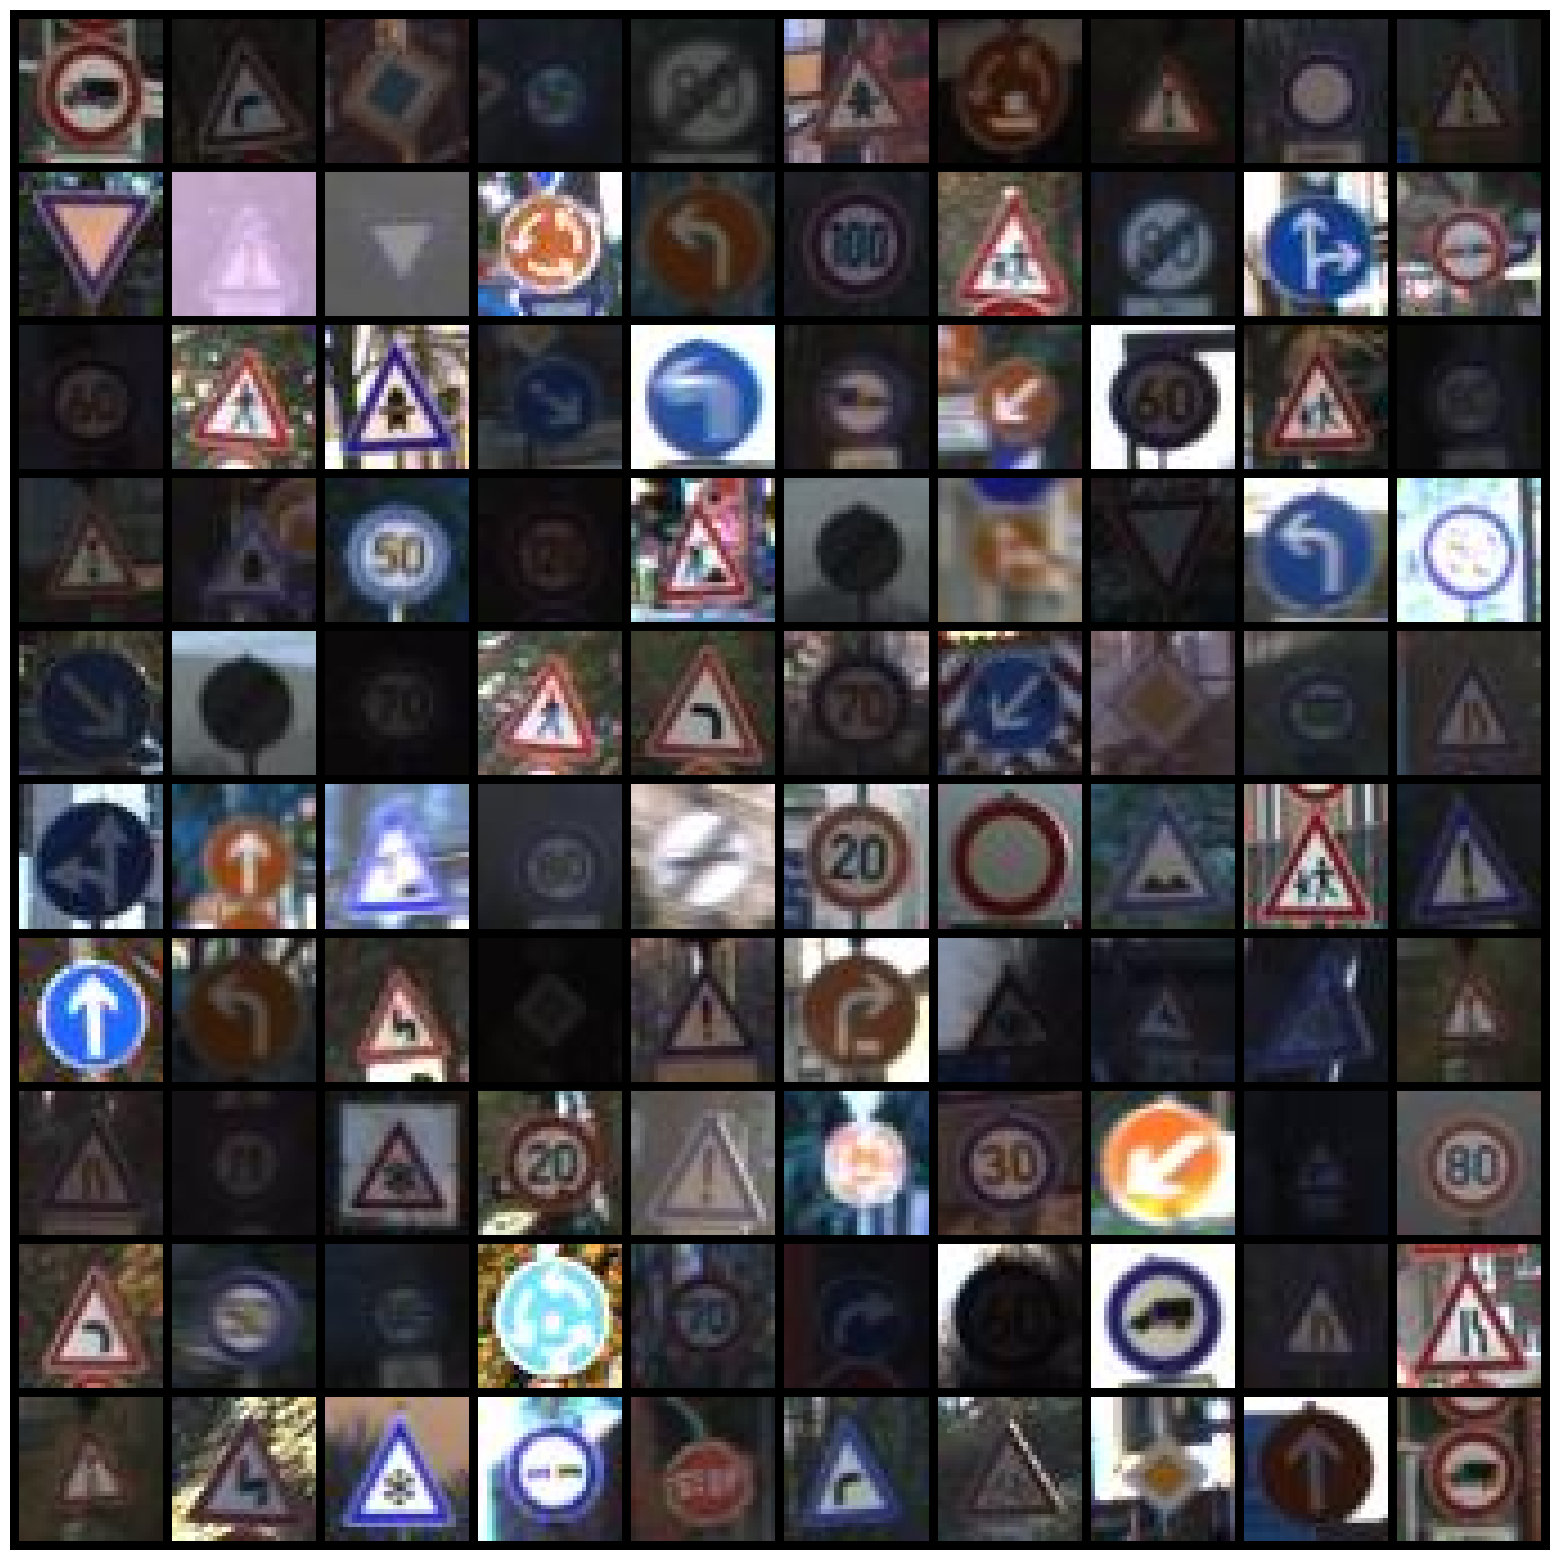



Labels of the above images :



array([16, 20, 12,  2,  6, 11, 40, 26, 15, 26, 13, 18, 13, 40, 34,  7, 28,
        6, 36,  9,  3, 27, 11, 38, 34, 10, 39,  3, 28,  5, 26, 11,  2,  8,
       25, 32, 36, 13, 34,  2, 38, 32,  4, 27, 19,  4, 39, 12,  7, 24, 37,
       35, 25,  5, 41,  0, 15, 22, 28, 18, 35, 34, 21, 12, 18, 33, 30, 31,
       29, 26, 24,  4, 30,  0, 18, 40,  1, 39, 20,  5, 19,  2,  5, 40,  4,
       33,  3, 16, 24, 24, 26, 21, 30,  9, 14, 20, 29, 12, 35, 16])

In [41]:
plt.figure(figsize=(20,20)) 
# make_grid creates a grid of 100 images and show it
plt.imshow(tv.utils.make_grid(torch.tensor(xtrain[:100]),nrow=10).permute(1,2,0))
plt.axis('off') # To remove xticks and yticks
plt.show()
print('\n\nLabels of the above images :\n')
ytrain[:100]

#### Convert train and test data from numpy array to tensor for further computations

In [42]:
xtrain = torch.from_numpy(xtrain) 
ytrain = torch.from_numpy(ytrain)
xtest = torch.from_numpy(xtest)
ytest = torch.from_numpy(ytest)

### Initialized the Neural Network Model 
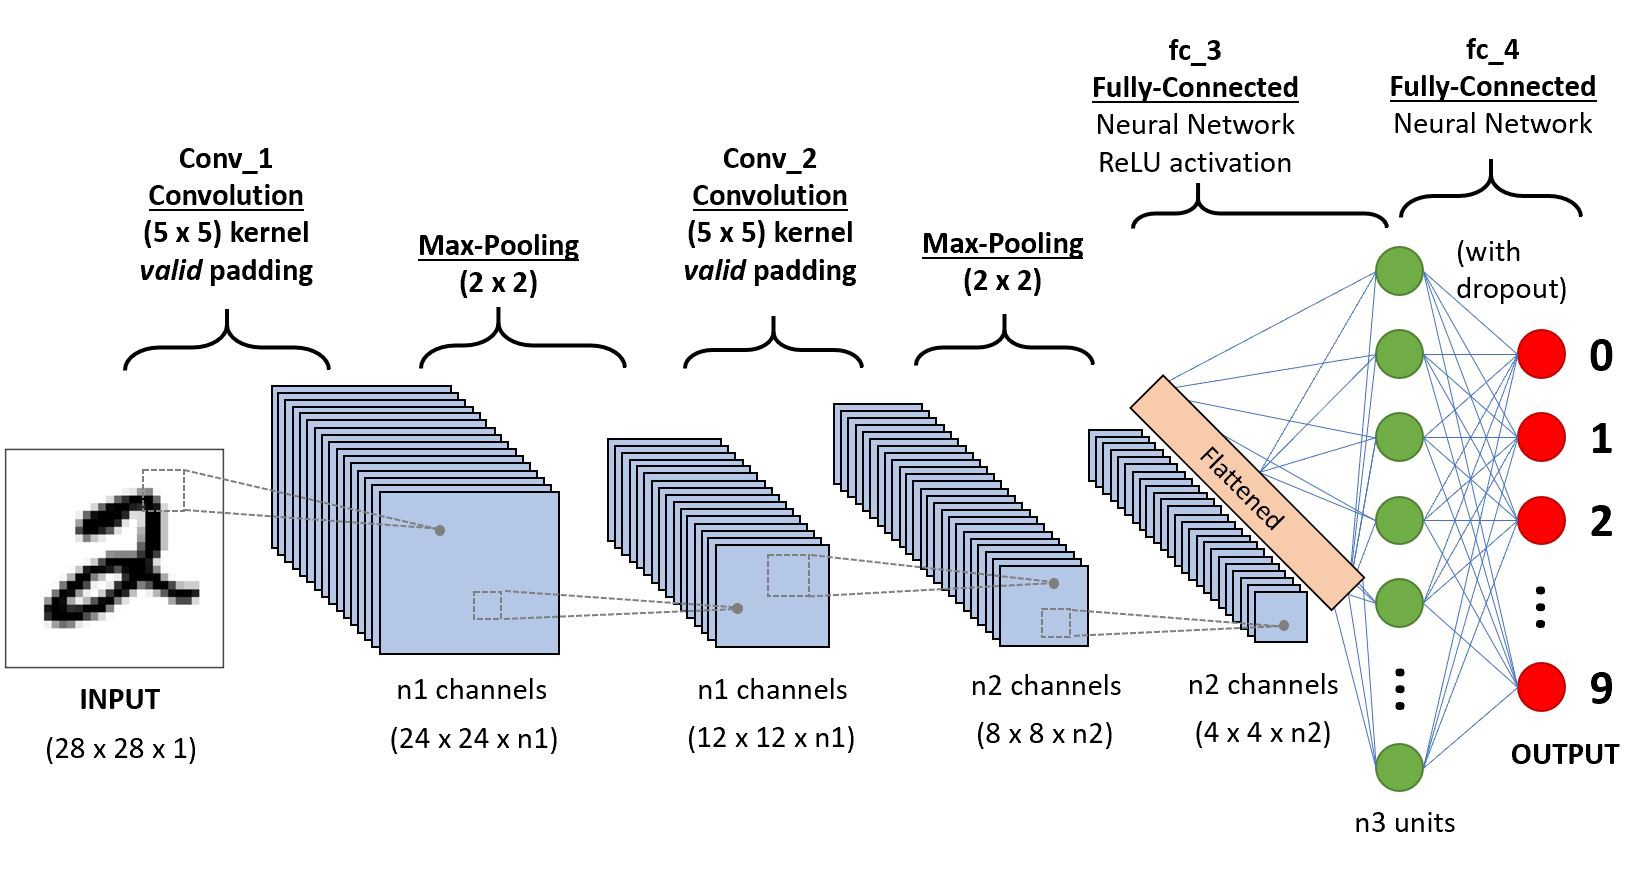

In [43]:
#!pip uninstall torch torchvision torchaudio -y

In [44]:
#!python -m pip install --upgrade pip

In [45]:
#!python --version

In [46]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [47]:
import torch

In [48]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX 3500 Ada Generation Laptop GPU


In [49]:
model = nn.Sequential(
                        # 1st convolutional network Layers
                        nn.Conv2d(3,16,(2,2),(1,1),'same'),   # Convolution
                        nn.BatchNorm2d(16),                   # Normalization 
                        nn.ReLU(True),                       # Activation
                        nn.MaxPool2d((2,2)),                 # Pooling
    
                        # 2nd convolutional network Layers
                        nn.Conv2d(16,32,(2,2),(1,1),'same'),  # Convolution
                        nn.BatchNorm2d(32),                  # Normalization 
                        nn.ReLU(True),                       # Activation
                        nn.MaxPool2d((2,2)),                 # Pooling
    
                        # 3rd convolutional network Layers
                        nn.Conv2d(32,64,(2,2),(1,1),'same'), # Convolution
                        nn.BatchNorm2d(64),                  # Normalization 
                        nn.ReLU(True),                       # Activation
                        nn.MaxPool2d((2,2)),                 # Pooling

                        # Flatten Data
                        nn.Flatten(),                        # Flatten
    
                        # feed forward Layers
                        nn.Linear(1024,256),                  # Linear 
                        nn.ReLU(True),                       # Activation
                        nn.Linear(256,43)                    # Linear 
                    )

# Send model to Cuda Memory
model = model.to(torch.device('cuda'),non_blocking=True)
# For Model Summary
ts.summary(model,(3,32,32))

c:\toolbase\python\3.12.13.1\Lib\site-packages\torch\nn\modules\conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv2d(


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             208
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
         MaxPool2d-4           [-1, 16, 16, 16]               0
            Conv2d-5           [-1, 32, 16, 16]           2,080
       BatchNorm2d-6           [-1, 32, 16, 16]              64
              ReLU-7           [-1, 32, 16, 16]               0
         MaxPool2d-8             [-1, 32, 8, 8]               0
            Conv2d-9             [-1, 64, 8, 8]           8,256
      BatchNorm2d-10             [-1, 64, 8, 8]             128
             ReLU-11             [-1, 64, 8, 8]               0
        MaxPool2d-12             [-1, 64, 4, 4]               0
          Flatten-13                 [-1, 1024]               0
           Linear-14                  [

In [50]:
# Calculate and save model statistics to JSON
import json

def count_parameters(model):
    """Count total and trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def format_params(num):
    """Format parameter count to readable string"""
    if num >= 1e6:
        return f"{num/1e6:.2f}M"
    elif num >= 1e3:
        return f"{num/1e3:.2f}K"
    return str(num)

def estimate_model_size(model):
    """Estimate model size in MB"""
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_mb = (param_size + buffer_size) / 1024**2
    return size_mb

def count_layers(model):
    """Count Conv and Dense (Linear) layers"""
    conv_layers = sum(1 for m in model.modules() if isinstance(m, nn.Conv2d))
    dense_layers = sum(1 for m in model.modules() if isinstance(m, nn.Linear))
    return conv_layers, dense_layers

# Calculate statistics
total_params, trainable_params = count_parameters(model)
model_size = estimate_model_size(model)
conv_layers, dense_layers = count_layers(model)

# Load existing hyperparameters and update statistics
hyperparams_path = 'hyperparameters.json'
with open(hyperparams_path, 'r', encoding='utf-8') as f:
    config = json.load(f)

config['statistics']['total_parameters'] = format_params(total_params)
config['statistics']['trainable_params'] = format_params(trainable_params)
config['statistics']['model_size'] = f"{model_size:.2f} MB"
config['statistics']['conv_layers'] = conv_layers
config['statistics']['dense_layers'] = dense_layers

# Save updated config (training_time will be updated after training)
with open(hyperparams_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Model Statistics saved to hyperparameters.json:")
print(f"  - Total Parameters: {format_params(total_params)}")
print(f"  - Trainable Params: {format_params(trainable_params)}")
print(f"  - Model Size: {model_size:.2f} MB")
print(f"  - Conv Layers: {conv_layers}")
print(f"  - Dense Layers: {dense_layers}")

Model Statistics saved to hyperparameters.json:
  - Total Parameters: 284.22K
  - Trainable Params: 284.22K
  - Model Size: 1.09 MB
  - Conv Layers: 3
  - Dense Layers: 2


#### Define the Evaluate Function for model loss and accuracy evaluation and Train Model Function to train the model

In [51]:
def evaluate(model, data, target):
    # sending data and target to cuda memory
    data = data.to(torch.device('cuda'),non_blocking=True)
    target = target.to(torch.device('cuda'),non_blocking=True)
    length = len(target)
    yhat = model(data) # predict on data
    ypred = yhat.argmax(axis=1) # claculate the prediction labels from yhat
    loss = float(nn.functional.cross_entropy(yhat, target)) # calculate the loss
    acc = float((ypred == target).sum() / length) # Calculate accuracy
    print('Loss :',round(loss,4),'- Accuracy :',round(acc,4)) # Print loss and Accuracy
    del data,target,yhat,ypred # delete the used variables
    torch.cuda.empty_cache() # Free the Cuda memory

#### Evaluate the Model on test data before training

In [52]:
print('\nInitial Loss and Accuracy on Test Dataset :')
evaluate(model,xtest.float(),ytest)


Initial Loss and Accuracy on Test Dataset :
Loss : 3.8079 - Accuracy : 0.0201


#### Define Train Model Function to train the model

In [53]:
    
def train_model(model=model,optimizer=torch.optim.Adam,epochs=5,batch_size=200,steps_per_epochs=200,l2_reg=0,max_lr=0.01,grad_clip=0.5):
    hist = [[],[],[],[]] # hist will stores train and test data losses and accuracy of every epochs
    
    train_ds = [(x,y) for x,y in zip(xtrain,ytrain)] # Prepare training dataset for Data Loader
    training_dl = torch.utils.data.DataLoader(train_ds,batch_size=batch_size) # Data Loader used to train model 
    train_dl = torch.utils.data.DataLoader(train_ds,batch_size=batch_size * steps_per_epochs) 
                                    # Data Loader for epoch end evaluation on train data
    del train_ds 
    gc.collect() # Delete the used variable and free up memory
    
    # Initialized the Optimizer to update weights and bias of model parameters
    optimizer = optimizer(model.parameters(),weight_decay=l2_reg)
    
    # Initialized the Schedular to update learning rate as per one cycle poicy  
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer,max_lr,epochs=epochs, steps_per_epoch=int(steps_per_epochs * 1.01))
        
    # Training Started
    for i in range(epochs):
                 
        print('\nEpoch' , i+1 , ': [',end="")
        
        # Load Batches of training data loader
        for j,(xb,yb) in enumerate(training_dl):
            
            # move the training batch data to cuda memory for faster processing
            xb = xb.to(torch.device('cuda'),non_blocking=True)
            yb = yb.to(torch.device('cuda'),non_blocking=True)
            
            # Calculate Losses and gradients
            yhat = model(xb.float())
            loss = nn.functional.cross_entropy(yhat, yb)
            loss.backward()
            
            # Clip the outlier like gradients
            nn.utils.clip_grad_value_(model.parameters(),grad_clip)
            
            # Update Weights and bias
            optimizer.step()
            optimizer.zero_grad()
            
            # Update Learning Rate
            sched.step()
            
            del xb,yb,yhat
            torch.cuda.empty_cache()
            # delete the used data and free up space
            
            # print the training epochs progress
            if j % int(steps_per_epochs / 20) == 0:
                print('.',end='')
                
            # break the loop when all steps of an epoch completed. 
            if steps_per_epochs == j :
                break
                             
           
        # Epochs end evaluation 
        
        device = torch.device('cuda') # initialized cuda to device
        
        # load training data batches from train data loader
        for xtrainb,ytrainb in train_dl:
            break
        
        # move train data to cuda
        xtrain_cuda = xtrainb.to(device,non_blocking=True)
        ytrain_cuda = ytrainb.to(device,non_blocking=True)
        del xtrainb, ytrainb
        gc.collect()
        # delete used variables and free up space
        
        # Calculate train loss and accuracy
        yhat = model(xtrain_cuda.float())
        ypred = yhat.argmax(axis=1)
        train_loss = float(nn.functional.cross_entropy(yhat, ytrain_cuda))
        train_acc = float((ypred == ytrain_cuda).sum() / len(ytrain_cuda))
        
        del xtrain_cuda, ytrain_cuda, yhat, ypred
        torch.cuda.empty_cache()
        # delete used variables and free up space
        
        # move test data to cuda
        xtest_cuda = xtest.to(device,non_blocking=True)
        ytest_cuda = ytest.to(device,non_blocking=True)
        
        # Calculate test loss and accuracy
        yhat = model(xtest_cuda.float())
        ypred = yhat.argmax(axis=1)
        val_loss = float(nn.functional.cross_entropy(yhat, ytest_cuda))
        val_acc = float((ypred == ytest_cuda).sum() / len(ytest_cuda))
        
        del xtest_cuda, ytest_cuda, yhat, ypred
        torch.cuda.empty_cache()
        # delete used variables and free up space
        
        # print the captured train and test loss and accuracy at the end of every epochs
        print('] - Train Loss :',round(train_loss,4),'- Train Accuracy :',round(train_acc,4),
              '- Val Loss :',round(val_loss,4), '- Val Accuracy :',round(val_acc,4))
        
        # store that data into the previously blank initialized hist list 
        hist[0].append(train_loss)
        hist[1].append(val_loss)
        hist[2].append(train_acc)
        hist[3].append(val_acc)
        
    # Initialized all the evaluation history of all epochs to a dict
    history = {'Train Loss':hist[0],'Val Loss':hist[1],'Train Accuracy':hist[2], 'Val Accuracy':hist[3]}
    
    # return the history as pandas dataframe
    return pd.DataFrame(history)

#### Train the Model

In [54]:
# Load hyperparameters from JSON file
import json

hyperparams_path = 'hyperparameters.json'
with open(hyperparams_path, 'r', encoding='utf-8') as f:
    config = json.load(f)

hp = config['hyperparameters']

# Map optimizer string to PyTorch optimizer
optimizer_mapping = {
    'Adam': torch.optim.Adam,
    'SGD': torch.optim.SGD,
    'RMSprop': torch.optim.RMSprop,
    'AdamW': torch.optim.AdamW,
}

selected_optimizer = optimizer_mapping.get(hp['optimizer'], torch.optim.Adam)

print(f"Loaded Hyperparameters from {hyperparams_path}:")
print(f"  - Learning Rate: {hp['learning_rate']}")
print(f"  - Batch Size: {hp['batch_size']}")
print(f"  - Epochs: {hp['epochs']}")
print(f"  - Optimizer: {hp['optimizer']}")

Loaded Hyperparameters from hyperparameters.json:
  - Learning Rate: 0.015
  - Batch Size: 200
  - Epochs: 15
  - Optimizer: Adam


In [55]:
import time as time_module

# Record start time
training_start_time = time_module.time()

# Use hyperparameters loaded from JSON file
history = train_model(
    model=model,
    optimizer=selected_optimizer,
    epochs=hp['epochs'],
    batch_size=hp['batch_size'],
    steps_per_epochs=200,
    l2_reg=0,
    max_lr=hp['learning_rate'],
    grad_clip=0.5
)

# Calculate training time
training_end_time = time_module.time()
training_time_seconds = training_end_time - training_start_time
training_time_minutes = training_time_seconds / 60

# Format training time
if training_time_minutes >= 60:
    hours = int(training_time_minutes // 60)
    mins = int(training_time_minutes % 60)
    training_time_str = f"~{hours}h {mins}m"
else:
    training_time_str = f"~{training_time_minutes:.1f} phút"

# Update hyperparameters.json with training time
hyperparams_path = 'hyperparameters.json'
with open(hyperparams_path, 'r', encoding='utf-8') as f:
    config = json.load(f)

config['statistics']['training_time'] = training_time_str

with open(hyperparams_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"\nTraining completed!")
print(f"Training time: {training_time_seconds:.2f} seconds ({training_time_str})")
print(f"Statistics saved to hyperparameters.json")


Epoch 1 : [.....................] - Train Loss : 0.4169 - Train Accuracy : 0.8845 - Val Loss : 0.4438 - Val Accuracy : 0.8774

Epoch 2 : [.....................] - Train Loss : 0.1524 - Train Accuracy : 0.9577 - Val Loss : 0.1904 - Val Accuracy : 0.9463

Epoch 3 : [.....................] - Train Loss : 0.1086 - Train Accuracy : 0.9677 - Val Loss : 0.1429 - Val Accuracy : 0.9578

Epoch 4 : [.....................] - Train Loss : 0.098 - Train Accuracy : 0.9719 - Val Loss : 0.1351 - Val Accuracy : 0.9623

Epoch 5 : [.....................] - Train Loss : 0.058 - Train Accuracy : 0.9817 - Val Loss : 0.0959 - Val Accuracy : 0.973

Epoch 6 : [.....................] - Train Loss : 0.0422 - Train Accuracy : 0.987 - Val Loss : 0.0802 - Val Accuracy : 0.978

Epoch 7 : [.....................] - Train Loss : 0.0243 - Train Accuracy : 0.9928 - Val Loss : 0.0605 - Val Accuracy : 0.9849

Epoch 8 : [.....................] - Train Loss : 0.022 - Train Accuracy : 0.9932 - Val Loss : 0.051 - Val Accuracy 

#### Model History

In [56]:
history

,Train Loss,Val Loss,Train Accuracy,Val Accuracy
0,0.416858,0.443816,0.884550,0.877411
1,0.152380,0.190432,0.957725,0.946327
2,0.108551,0.142887,0.967750,0.957813
3,0.097973,0.135095,0.971925,0.962280
4,0.057999,0.095923,0.981725,0.973034
5,0.042225,0.080176,0.987000,0.978020
6,0.024251,0.060471,0.992775,0.984851
7,0.022025,0.050983,0.993175,0.985512
8,0.015480,0.046612,0.995750,0.988797
9,0.002737,0.032399,0.999175,0.992603


In [57]:
import json

loss_data = {
    "data": [
        {
            "Epoch": int(idx),
            "Train Loss": float(row['Train Loss']),
            "Val Loss": float(row['Val Loss'])
        }
        for idx, row in history.iterrows()
    ]
}

with open('history_loss.json', 'w', encoding='utf-8') as f:
    json.dump(loss_data, f, indent=2, ensure_ascii=False)

accuracy_data = {
    "data": [
        {
            "Epoch": int(idx),
            "Train Accuracy": float(row['Train Accuracy']),
            "Val Accuracy": float(row['Val Accuracy'])
        }
        for idx, row in history.iterrows()
    ]
}

with open('history_accuracy.json', 'w', encoding='utf-8') as f:
    json.dump(accuracy_data, f, indent=2, ensure_ascii=False)

In [58]:
import json

history_data = {
    "data": [
        {
            "epoch": int(idx) + 1,
            "trainAcc": float(row['Train Accuracy']),
            "valAcc": float(row['Val Accuracy']),
            "trainLoss": float(row['Train Loss']),
            "valLoss": float(row['Val Loss'])
        }
        for idx, row in history.iterrows()
    ]
}

with open('history.json', 'w', encoding='utf-8') as f:
    json.dump(history_data, f, indent=2, ensure_ascii=False)


#### Visualize the Training History

In [59]:
# used plotly for interactive plotting
fig = px.line(history.iloc[:,:2],title='Loss Per Epochs',labels={'value':'Loss','index':'Epochs'})
fig.update_layout(title={'font_family':'Georgia','font_size':23,'x':0.5}).show()
fig = px.line(history.iloc[:,2:],title='Accuracy Per Epochs',labels={'value':'Accuracy','index':'Epochs'})
fig.update_layout(title={'font_family':'Georgia','font_size':23,'x':0.5}).show() 

#### Model Classification Report on Test Data

In [60]:
# move to cuda 
xtest =  xtest.to(torch.device('cuda'),non_blocking=True)
# generate predictions
model.eval()
with torch.no_grad():
    ypred = model(xtest.float()).argmax(dim=1)
# again move back xtest , ypred to cpu
#xtest = xtest.to(torch.device('cpu'),non_blocking=True)
#ypred = ypred.to(torch.device('cpu'),non_blocking=True)
# move về CPU + numpy
ypred = ypred.cpu().numpy()

# if isinstance(ytest, torch.Tensor):
#     ytest = ytest.cpu().numpy()
report_dict = classification_report(ytest, ypred, output_dict=True)
print(report_dict)

accuracy = report_dict["accuracy"]
macro_avg = report_dict["macro avg"]
print(accuracy)
print(macro_avg["precision"])

# Format as summaryCards
summary_data = {
    "summaryCards": [
        {
            "title": "Accuracy",
            "value": f"{accuracy * 100:.5f}%",
            "subtitle": "Model CNN v2.1 - Test set",
            "icon": "A",
            "className": "accuracy"
        },
        {
            "title": "Precision",
            "value": f"{macro_avg["precision"] * 100:.5f}%",
            "subtitle": "Model CNN v2.1 - Test set",
            "icon": "P",
            "className": "precision"
        },
        {
            "title": "Recall",
            "value": f"{macro_avg["recall"] * 100:.5f}%",
            "subtitle": "Model CNN v2.1 - Test set",
            "icon": "R",
            "className": "recall"
        },
        {
            "title": "F1-Score",
            "value": f"{macro_avg["f1-score"] * 100:.5f}%",
            "subtitle": "Model CNN v2.1 - Test set",
            "icon": "F",
            "className": "f1"
        }
    ]
}

# Save to JSON file
with open('classification_report.json', 'w', encoding='utf-8') as f:
    json.dump(summary_data, f, indent=2, ensure_ascii=False)
print("Model device:", next(model.parameters()).device)
print("First weight mean:", next(model.parameters()).mean().item())

{'0': {'precision': 0.9979716024340771, 'recall': 1.0, 'f1-score': 0.9989847715736041, 'support': 984.0}, '1': {'precision': 0.9926854754440961, 'recall': 0.9654471544715447, 'f1-score': 0.9788768675940237, 'support': 984.0}, '2': {'precision': 0.979757085020243, 'recall': 0.983739837398374, 'f1-score': 0.9817444219066938, 'support': 984.0}, '3': {'precision': 0.9757820383451059, 'recall': 0.9827235772357723, 'f1-score': 0.979240506329114, 'support': 984.0}, '4': {'precision': 0.983789260385005, 'recall': 0.9867886178861789, 'f1-score': 0.9852866565195332, 'support': 984.0}, '5': {'precision': 0.97165991902834, 'recall': 0.975609756097561, 'f1-score': 0.973630831643002, 'support': 984.0}, '6': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 984.0}, '7': {'precision': 0.9835897435897436, 'recall': 0.9745934959349594, 'f1-score': 0.9790709545686574, 'support': 984.0}, '8': {'precision': 0.9838220424671386, 'recall': 0.9888211382113821, 'f1-score': 0.9863152559553978, 'suppo

In [61]:
# # move to cuda 
# xtest =  xtest.to(torch.device('cuda'),non_blocking=True)
# # generate predictions
# ypred = model(xtest.float()).argmax(axis=1)
# # again move back xtest , ypred to cpu
# xtest = xtest.to(torch.device('cpu'),non_blocking=True)
# ypred = ypred.to(torch.device('cpu'),non_blocking=True)

# report_dict = classification_report(ytest, ypred, output_dict=True)
# print(report_dict)

# accuracy = report_dict["accuracy"]
# macro_avg = report_dict["macro avg"]
# print(accuracy)
# print(macro_avg["precision"])

# # Format as summaryCards
# summary_data = {
#     "summaryCards": [
#         {
#             "title": "Accuracy",
#             "value": f"{accuracy * 100:.0f}%",
#             "subtitle": "Model CNN v2.1 - Test set",
#             "icon": "A",
#             "className": "accuracy"
#         },
#         {
#             "title": "Precision",
#             "value": f"{macro_avg["precision"] * 100:.0f}%",
#             "subtitle": "Model CNN v2.1 - Test set",
#             "icon": "P",
#             "className": "precision"
#         },
#         {
#             "title": "Recall",
#             "value": f"{macro_avg["recall"] * 100:.0f}%",
#             "subtitle": "Model CNN v2.1 - Test set",
#             "icon": "R",
#             "className": "recall"
#         },
#         {
#             "title": "F1-Score",
#             "value": f"{macro_avg["f1-score"] * 100:.0f}%",
#             "subtitle": "Model CNN v2.1 - Test set",
#             "icon": "F",
#             "className": "f1"
#         }
#     ]
# }

# # Save to JSON file
# with open('classification_report.json', 'w', encoding='utf-8') as f:
#     json.dump(summary_data, f, indent=2, ensure_ascii=False)

#### Create the Prediction Function

In [62]:
def prediction(img):
    if type(img) == str:
        # PIL load the image as PIL object and ToTensor() convert this to a Tensor
        img = tv.transforms.ToTensor()(PIL.Image.open(img))
    # resize image to 32X32 as model supports this
    img = cv2.resize(img.permute(1,2,0).numpy(),(32,32))
    img = torch.from_numpy(img).permute(2,0,1)
    # unsqueezed img as inside a tensor and move to cuda
    img_tensor = img.unsqueeze(0).to(torch.device('cuda'))
    # Predict the label
    output = model(img_tensor.float())
    pred = int(output.argmax(axis=1)[0])
    # Find the traffic sign name for label from labels_df 
    # that initialize at the begining of the notebook
    pred_str = labels_df[labels_df['ClassId'] == pred]['Name'][pred]
    # Show the image using matplotlib
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.resize(img.permute(1,2,0).numpy(),(1000,1000)))
    plt.axis('off')
    # Print traffic sign that recognized
    print('\nRecognized Traffic Sign :',pred_str,'\n')
    print(f"Max Confidence : {output.softmax(dim=1).max().item():.4f}")

#### Some Examples of the above Prediction Function


Recognized Traffic Sign : Road work 

Max Confidence : 0.9043


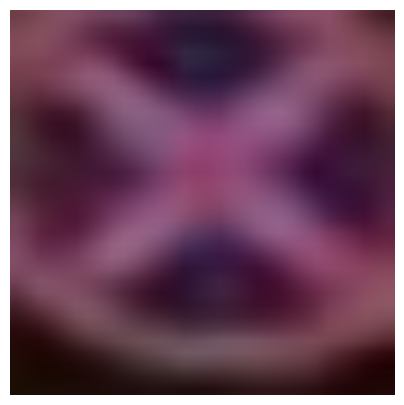

In [63]:
prediction('C:/Users/TDA5HC/Desktop/Documents/01_CS_Master/07_MachineLearning/BTL/RCNN_crop_object_scthr0-1/AUTO_COLLECTED_PICTURE_72_png.rf.2c59c79ca8ae178ee67a65a5af799e73_roi_2.png')

##### Example 1


Recognized Traffic Sign : No entry 

Max Confidence : 1.0000


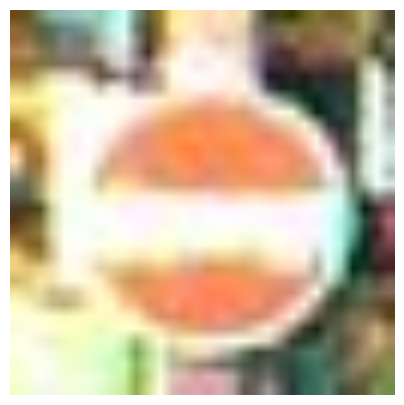

In [64]:
prediction('../../dataset/Data/17/00000_00004.jpg')


Recognized Traffic Sign : General caution 

Max Confidence : 0.8865


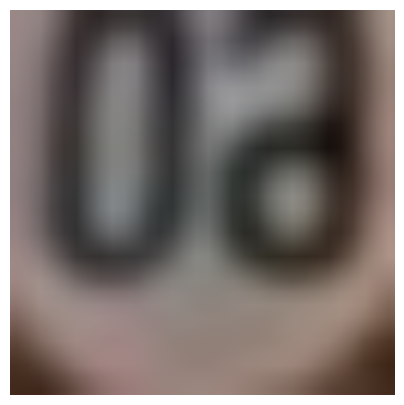

In [65]:
prediction('C:/Users/TDA5HC/Desktop/Documents/01_CS_Master/07_MachineLearning/BTL/RCNN_crop_object_scthr0-1/AUTO_COLLECTED_PICTURE_220_png.rf.d14580f18ba49a6166ff2896570c620d_roi_1.png')

##### Example 2


Recognized Traffic Sign : Speed limit (50km/h) 

Max Confidence : 1.0000


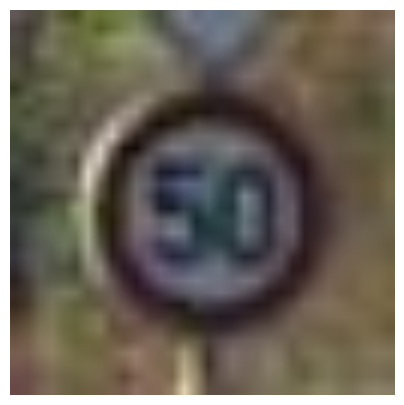

In [66]:
prediction('../../dataset/Data/2/00000_00017.jpg')

##### Example 3


Recognized Traffic Sign : Speed limit (30km/h) 

Max Confidence : 1.0000


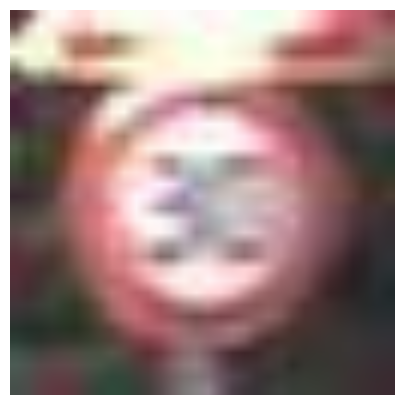

In [67]:
prediction('../../dataset/Data/1/00000_00000.jpg')

##### Example 4


Recognized Traffic Sign : Speed limit (100km/h) 

Max Confidence : 1.0000


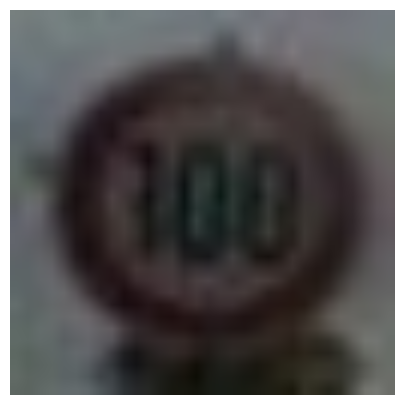

In [68]:
prediction('../../dataset/Data/7/00000_00025.jpg')

##### Example 5


Recognized Traffic Sign : Stop 

Max Confidence : 1.0000


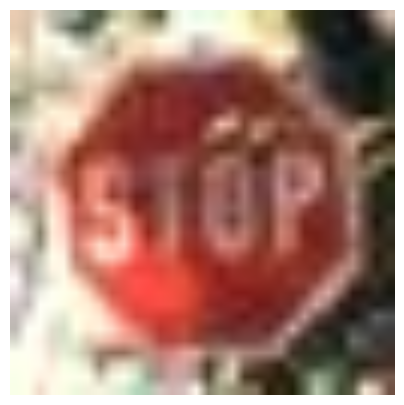

In [69]:
prediction('../../dataset/Data/14/00000_00019.jpg')

#### Save the Model

In [ ]:
torch.save(model,'../../model/CNN/traffic_sign_recognition.pt')